# Notebook Example Analysis

## 1. Import data

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from coloured_line_points import colored_line
import numpy as np

In [2]:
#csv wealther anomaly data from BOM -  Australian climate variability & change - Time series graphs
#https://www.bom.gov.au/cgi-bin/climate/change/timeseries.cgi?graph=dtr&area=aus&season=allmonths&ave_yr=0&ave_period=6190

#get data folder path
data_folder = os.path.join(os.getcwd(), r'raw data')


## 2. Transform Data

In [3]:
#get list of CSV names in folder
files = os.listdir(data_folder)

#iteratively extract data and merge them into one dataframe.
counter = 1 
for i in files:
    #import csv
    raw_data_path = os.path.join(data_folder, i)
    data = pd.read_csv(raw_data_path)
    #unpivot monthly data
    df_long = data.melt(id_vars=['Year'], 
                  var_name='Month', 
                  value_name=i)
    #fix up date columns
    df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + df_long['Month'], format='%Y%b')

    
    #iteratively join data together to get one table at the end
    if counter == 1:
        weather_data = df_long[['Date',i]]
        counter += 1 
    else:
        weather_data_temp = df_long[['Date',i]]
        weather_data = pd.merge(weather_data, weather_data_temp[['Date',i]], on='Date', how='left')

#sort values and make new copy
weather_data = weather_data.sort_values( 'Date').copy()

#delete unused dfs
del weather_data_temp, df_long , data

In [4]:
#add simplified yyyy-mm column from date
weather_data['Year Month'] = weather_data['Date'].dt.strftime('%Y-%m')

#check for nulls
weather_data['nulls'] = weather_data[files].sum(axis=1,skipna=False)

max_date = max(weather_data['Date'].loc[weather_data['nulls'].notna()] )
print('Max Date without Nulls:', max_date)

#remove nulls, while allowing for genuine nulls in the range of the data.
weather_data = weather_data.loc[weather_data['Date'] <= max_date].copy()

#list(weather_data.columns)

#rename col names
new_names = {"dtr.aus.allmonths.3342.csv": "dtr_anomaly",
              "rain.aus.allmonths.636.csv": "rain",
              "tmax.aus.allmonths.29355.csv": "tmax_anomaly",
                "tmean.aus.allmonths.12197.csv": "tmean_anomaly" }

weather_data = weather_data.rename(columns=new_names)

#reorder and redo index
weather_data  = weather_data[['Date',
                            'Year Month',
                            'tmean_anomaly',
                            'tmax_anomaly',
                            'rain',
                            'dtr_anomaly']].reset_index(drop=True)

Max Date without Nulls: 2026-01-01 00:00:00


In [5]:
#final processed dataframe
weather_data

,Date,Year Month,tmean_anomaly,tmax_anomaly,rain,dtr_anomaly
0,1910-01-01,1910-01,-0.22,-0.13,78.01,0.19
1,1910-02-01,1910-02,-0.32,-0.15,73.68,0.37
2,1910-03-01,1910-03,-1.82,-2.19,82.62,-0.71
3,1910-04-01,1910-04,-0.29,-0.26,29.10,0.07
4,1910-05-01,1910-05,0.23,0.17,29.62,-0.10
...,...,...,...,...,...,...
1388,2025-09-01,2025-09,1.13,1.46,14.27,0.67
1389,2025-10-01,2025-10,2.53,2.81,23.61,0.57
1390,2025-11-01,2025-11,0.60,0.52,45.18,-0.15
1391,2025-12-01,2025-12,1.03,1.27,71.87,0.49


## 3. Create plots

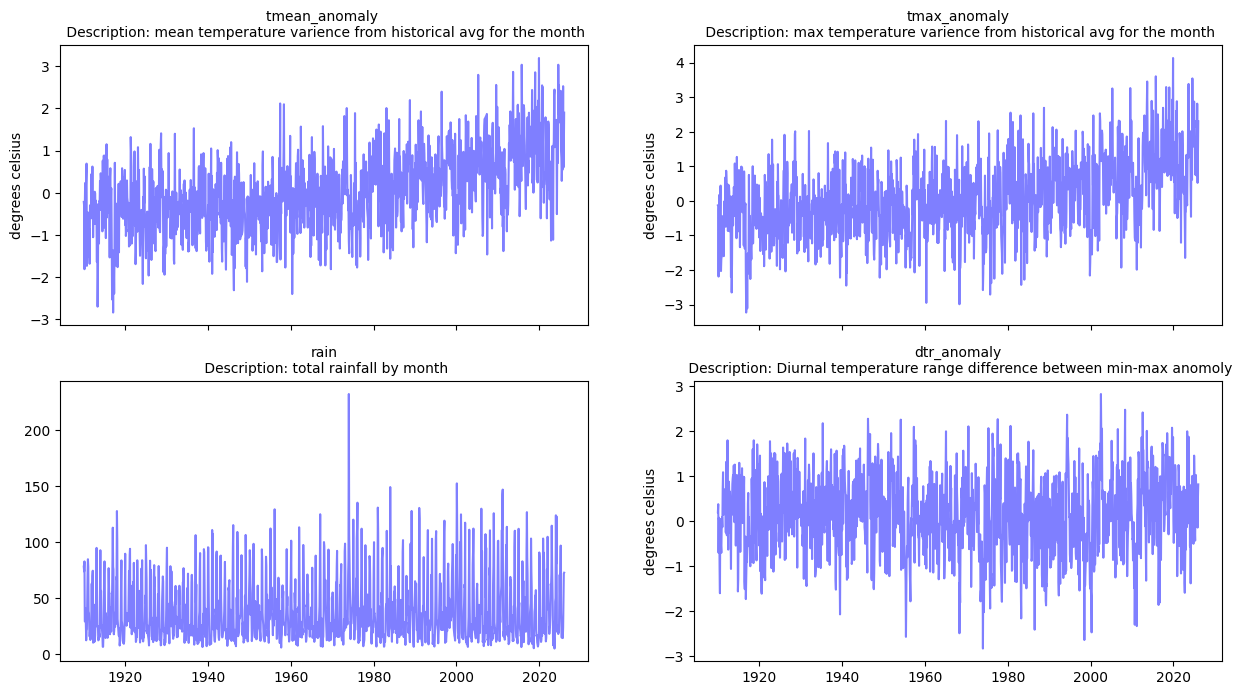

In [6]:
#create subplots to fill
fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

font_size = 10

#generate timeseries plots
axs[0, 0].plot(weather_data['Date'],weather_data['tmean_anomaly'],  color='b', alpha=0.5)
axs[0, 0].set_title('tmean_anomaly \n Description: mean temperature varience from historical avg for the month',  fontsize=font_size )
axs[0, 0].set_ylabel('degrees celsius',  fontsize=font_size )

axs[0, 1].plot(weather_data['Date'],weather_data['tmax_anomaly'],   color='blue', alpha=0.5)
axs[0, 1].set_title('tmax_anomaly\n Description: max temperature varience from historical avg for the month',  fontsize=font_size )
axs[0, 1].set_ylabel('degrees celsius',  fontsize=font_size )

axs[1, 0].plot(weather_data['Date'],weather_data['rain'],  color='blue', alpha=0.5)
axs[1, 0].set_title('rain\n Description: total rainfall by month',  fontsize=font_size )


axs[1, 1].plot(weather_data['Date'],weather_data['dtr_anomaly'], color='blue', alpha=0.5)
axs[1, 1].set_title('dtr_anomaly\n Description: Diurnal temperature range difference between min-max anomoly',  fontsize=font_size )
axs[1, 1].set_ylabel('degrees celsius',  fontsize=font_size )

plt.show()


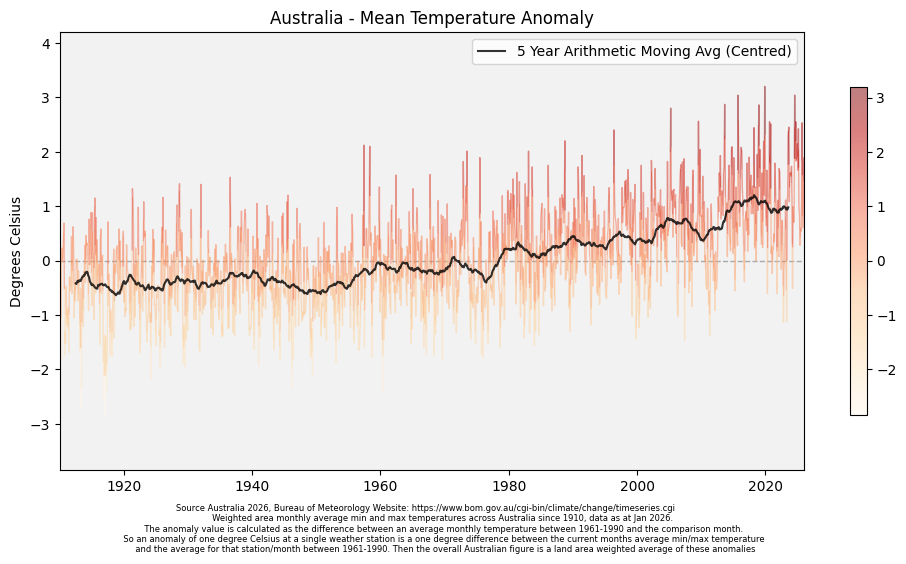

In [ ]:
#gradient over timeseries for publish quality graph

#create subplot to fill
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 6))

#set up arrays, the function colored line requires numpy arrays not pandas columns as inputs
colour = np.array(weather_data['tmean_anomaly'])
x_dates = weather_data['Date']
x_axis = mdates.date2num(x_dates) 
length = len(x_axis)
y_axis = np.array(weather_data['tmean_anomaly'])

##set up arithmetic moving average
window_size = 12*5 #5 years 
moving_avg = pd.Series(weather_data['tmean_anomaly']).rolling(window=window_size,center=True).mean() #center=True

#plot lineplot with gradient

line = colored_line(x_axis, y_axis, colour , ax2, linewidth=1, cmap="OrRd", alpha =0.5)
fig2.colorbar(line, ax=ax2,location='right', shrink=0.75)

ax2.plot(x_axis, moving_avg, label=f'{int(window_size/12)} Year Arithmetic Moving Avg (Centred)', color = 'black', alpha = 0.8 )
ax2.set_xlim(0, length)
ax2.set_title('Australia - Mean Temperature Anomaly')
ax2.set_ylabel('Degrees Celsius')
ax2.set_ylim(min(y_axis) - 1, max(y_axis) +1)
ax2.legend(loc='upper right', frameon=True, facecolor='white')

#add 0 line and grey background
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.3, zorder=1)
ax2.set_facecolor('#f2f2f2')

#turn numbers in xaxis back into dates.
ax2.xaxis_date() 
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlim(min(weather_data['Date']), max(weather_data['Date']))

# #add text box
caveat_text = '''Source Australia 2026, Bureau of Meteorology Website: https://www.bom.gov.au/cgi-bin/climate/change/timeseries.cgi
             Weighted area monthly average min and max temperatures across Australia since 1910, data as at Jan 2026.
               The anomaly value is calculated as the difference between an average monthly temperature between 1961-1990 and the comparison month. 
               So an anomaly of one degree Celsius at a single weather station is a one degree difference between the current months average min/max temperature 
               and the average for that station/month between 1961-1990. Then the overall Australian figure is a land area weighted average of these anomalies'''
# Add text to the figure
# Adjust bottom margin to make space for text
plt.subplots_adjust(bottom=0.15)
fig2.text(0.43, 0.01, caveat_text, ha='center', va='bottom', fontsize=6, color='black')

plt.show()
